# S&P 500 Options - Strategy Analysis

This notebook converts the case-study backtest registry for the S&P
500 options HTM straddle strategy into a per-case-study strategy
assessment. Which configuration carries it is resolved from the registry in
§1 and printed there, not named here: it is a property of the run and it moves
whenever the sweep is rebuilt, and a name written into prose agrees with the
registry only until the next rebuild. What is fixed is the selection contract
- the liquid-universe pin is applied first, then the surface is ranked on
validation, and the holdout is not consulted.
All `ret_to_expiry` backtests dispatch
through the HTM daily-MTM cohort engine (`_run_htm_daily_mtm`): entry on
the final available session of each Friday week, the underlying delta
hedged whenever it breaches its threshold, settle at intrinsic value at
expiration, full per-leg costs (entry-side option spread, underlying hedge
spread on each session the hedge trades, and an exit-leg option trade only
where a contract's chain ends before its expiration date). Every metric is reported with its
block-bootstrap 95% CI; paired holdout comparisons via
`backtest_paired_metrics` are required before the notebook reports them.
Cross-case-study comparison is reserved for Chapter 20.

**Learning objectives**

- Read uncertainty-aware backtest metrics for an options strategy whose
  signal is statistically null (Sharpe and IC both straddle zero) under
  HTM cost accounting on full per-leg friction.
- Surface a holdout decay reading without invoking champion/winner/
  verdict language, and a holdout-vs-EW comparison for the same window.

**Book reference**: Chapter 20, §20.1 - sp500_options anchors the
"cost model validity" theme in the cross-case-study synthesis.

**Prerequisites**: case-study pipeline through `12_backtest` and
`15_costs`; the locked registry at
`case_studies/sp500_options/run_log/registry.db`.

**Scope**: registry-read only - no training, no re-backtesting, no
registry writes. The `backtest_paired_metrics` table was populated by
`20_strategy_synthesis/01_aggregate_synthesis.py` (commit `57677ce`).

In [1]:
"""S&P 500 Options - Strategy Analysis."""

# ruff: noqa: E402, I001

import json
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch  # ml4t.diagnostic loads cudart; torch must import first
import yaml

warnings.filterwarnings("ignore")

from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)

Load the registry readers and reporting helpers the notebook draws on.

In [2]:
from case_studies.research import CandidateSet, OfficialPopulation, Study
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.cohort_metrics import compute_and_register
from case_studies.utils.cohort_reporting import cohort_metric_attribution, reportable_pbo
from case_studies.utils.paired_metrics import populate_paired_metrics, rung_for
from case_studies.utils.uncertainty import cohort_member_digest
from case_studies.utils.factor_attribution import (
    compute_bootstrap_ci,
    format_attribution_summary,
    load_factor_data,
    plot_attribution_waterfall,
    run_factor_regression,
)
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    compute_operating_profile,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    gate_passes,
    plot_equity_drawdown,
    resolve_canonical_rank1_lineage,
    write_strategy_assessment,
)
from utils.paths import get_case_study_dir, get_output_dir

In [3]:
MAX_SYMBOLS = 0

In [4]:
CASE_STUDY = "sp500_options"
# The immutable grid `12_backtest` publishes; the DSR below deflates for its members.
BASELINE_POPULATION = "sp500-options-baseline-validation-v1"
# The nominees `13_portfolio_management` publishes; the carrier has to be one of them.
STRATEGY_CANDIDATES = "sp500-options-strategy-candidates-v1"
PRIMARY_LABEL = "ret_to_expiry"  # registered HTM strategy label (Appendix A)
PERIODS_PER_YEAR = 252
CASE_DIR = get_case_study_dir(CASE_STUDY)
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
_selection_study = Study.open(CASE_STUDY)
print(explorer)

BacktestExplorer('sp500_options', 1665 runs: allocation=60, cost_sensitivity=32, holdout=1, signal=1572)


Format point estimates and confidence intervals consistently throughout
the notebook.

In [5]:
def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    if point is None:
        return "-"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [-, -]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"

Format scalar metrics while preserving missing values.

In [6]:
def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "-" if val is None else format(val, fmt)

## §1 Handoff from model analysis

The strategy phase inherits an HTM short-straddle pipeline: weekly
entry on a top-k cross-section of `ret_to_expiry`, daily delta hedge
through the underlying, hold to expiry, full per-leg costs on entry-side
option spread plus daily underlying hedge spread, and an exit-leg option
trade only where a contract's chain ends before its expiration date. The
family, configuration and allocator that carry it are resolved from the
registry below and printed alongside their identifiers rather than named
here. The
liquid universe pin (`UNIVERSE_RESTRICTIONS`) excludes the higher-Sharpe
full-universe rows from rank-1 selection, so the deployed carrier stays on
the liquid subset and remains poolable with its holdout replay. The carrier
is fixed before the one holdout evaluation. The upstream
prediction-side IC and the downstream strategy Sharpe are both
statistically consistent with zero - there is no IC-vs-Sharpe disconnect
on this strategy; both metrics agree that no edge has been resolved on
`ret_to_expiry` over the validation window. `LABEL_RESTRICTIONS` excludes
the four diagnostic `fwd_ret_*` variants from rank-1 selection (and those
rows have been dropped from the registry entirely as of the 2026-05-17
sweep cleanup); the only label that anchors a registered rank-1 here is
`ret_to_expiry` under HTM cost accounting.

In [7]:
# Rank-1 = the registered HTM strategy on ret_to_expiry. Resolved
# dynamically from the registry with LABEL_RESTRICTIONS applied so any
# residual diagnostic-variant rows (fwd_ret_5d/_10d/_dh_*) - which inflated
# Sharpes under bps-of-notional costs and cannot anchor a registered HTM
# strategy - are excluded from the cross-stage rank-1 lookup. The val/
# holdout pair shares a training_hash; the notebook reads from those rows
# rather than recomputing.
# The nominated field is resolved BEFORE the ranking and handed to it, not checked against
# the winner afterwards. Those are different tests wherever the conformal branch is taken:
# the common-support re-ranking restricts every series to the timestamps they all share, so a
# row that is never going to win still decides how far that intersection reaches, and
# therefore which admitted candidate does. A membership check on the winner passes while the
# answer has already been moved by a row that was never eligible.
_candidate_hashes = frozenset(CandidateSet.one(_selection_study, name=STRATEGY_CANDIDATES).members)
_lineage = resolve_canonical_rank1_lineage(CASE_STUDY, admitted=_candidate_hashes)
TOP_HASH = _lineage["val_backtest_hash"]
TOP_PHASH = _lineage["val_prediction_hash"]
HO_HASH = _lineage["holdout_backtest_hash"]
HO_PHASH = _lineage["holdout_prediction_hash"]
RANK1_FAMILY = _lineage["family"]
RANK1_CONFIG = _lineage["config_name"]
assert _lineage["label"] == PRIMARY_LABEL, (
    f"Canonical rank-1 label {_lineage['label']!r} != PRIMARY_LABEL "
    f"{PRIMARY_LABEL!r} - LABEL_RESTRICTIONS misconfigured?"
)
assert HO_HASH is not None, (
    "No holdout backtest for the canonical val rank-1. Run "
    "16_holdout_predictions and 17_holdout_backtest, which refit the carrier over the "
    "holdout interval and register the result under a training identity of its own. Do not "
    "reach for 20_strategy_synthesis/holdout.py::generate_holdout: it registers its "
    "predictions under the VALIDATION training identity, so what it produces is a "
    "validation-fitted model scored on the holdout window, which is the one thing the "
    "holdout exists to rule out."
)
# The field was applied before the ranking, so this cannot fail on a row from outside it.
# It stays because it is cheap and because it is the assertion a reader needs: the carrier
# published below is one of the nominees `13_portfolio_management` froze, not whatever
# happened to rank first in the registry.
if TOP_HASH not in _candidate_hashes:
    raise RuntimeError(
        f"Canonical rank-1 {TOP_HASH} is not a member of {STRATEGY_CANDIDATES} "
        f"({len(_candidate_hashes)} nominees), so the carrier was ranked from outside the "
        "set this case study nominated"
    )

### The paired rows this notebook reads, built here rather than assumed

§6 reads two `backtest_paired_metrics` kinds keyed on the holdout backtest, and it used to
load rows that only `20_strategy_synthesis/01_aggregate_synthesis.py` ever wrote. On a
registry that has been reset, or one whose carrier moved, those rows are absent or belong to
a holdout hash that no longer exists, and the notebook stopped on a message telling the
reader to populate the case elsewhere. A case study's own pipeline has to be able to produce
everything its own notebooks report.

`populate_paired_metrics` is the same producer Chapter 20 calls, and it is given the same
selection this notebook made: the carrier from the lineage resolver, and the rung this case
study is pinned to. The pin matters here - rung-1 (mid-to-mid bps) and rung-2 (full-universe
HTM) both carry `universe_filter="full"`, so ranking on the universe alone would let either
stand in for the liquid carrier the case study actually deploys.

`replace_all` makes the call a snapshot. Registration is an upsert keyed on
`(challenger_hash, benchmark_hash)`, so it can add this carrier's rows and cannot remove the
rows of a carrier it replaced; those rows name a holdout hash that is no longer the holdout
and would sit in the table looking current. This case study restricts to one label and one
rung, so what the call writes is the whole of what belongs here, which is the condition
under which pruning to it is right.

In [8]:
# `cohort_metrics` is the same story one table over: this notebook reads the cross-family
# baseline cohort and the deflated Sharpe computed over it, and only Chapter 20 ever wrote
# them. `compute_and_register` is that producer, and it refreshes the whole table rather than
# one row, so it also removes a cohort led by a backtest the registry no longer holds. The
# universe pin goes with it - the full-universe rows are kept for the Chapter 18 cost cascade
# and must not enter a cohort the carrier is deflated against.
_cohort_counts = compute_and_register(
    CASE_STUDY,
    universe_filter=rung_for(CASE_STUDY)["universe_filter"],
    verbose=False,
)
print(
    f"cohort_metrics: {sum(v for k, v in _cohort_counts.items() if k not in ('errors', 'dangling_pruned'))} "
    f"rows across {sorted(k for k in _cohort_counts if k not in ('errors', 'dangling_pruned'))}"
    f", {_cohort_counts['dangling_pruned']} dangling pruned, {_cohort_counts['errors']} errors"
)

cohort_metrics: 16 rows across ['family', 'label', 'stagelabel'], 0 dangling pruned, 0 errors


In [9]:
_paired_rows = populate_paired_metrics(
    CASE_STUDY,
    explorer,
    label_restriction=frozenset({PRIMARY_LABEL}),
    rung=rung_for(CASE_STUDY),
    carrier=_lineage,
    periods_per_year=PERIODS_PER_YEAR,
    replace_all=True,
    verbose=False,
)
_written = [row for row in _paired_rows if "skip" not in row]
print(f"backtest_paired_metrics: {len(_written)} pairs written, {len(_paired_rows)} attempted")
for _row in _paired_rows:
    if "skip" in _row:
        print(f"  skipped {_row.get('benchmark_kind', '?')}: {_row['skip']}")

backtest_paired_metrics: 4 pairs written, 4 attempted


Resolve the carrier's prediction metrics and registered strategy
specification directly from the registry.

In [10]:
_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_db)) as _con:
    _row = _con.execute(
        "SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac, ic_n_days, "
        "ic_hac_lag, ic_pct_positive "
        "FROM prediction_metrics WHERE prediction_hash = ?",
        (TOP_PHASH,),
    ).fetchone()
    # Resolve universe_filter and allocator from the rank-1 backtest spec.
    # universe_filter encodes the O'Donovan & Yu 2024 cost-mitigation cascade
    # rung: "full" = rung-2 (whole surface), "liquid" = rung-3 (liquid subset).
    # A missing / null filter means the rank-1 ran on the full surface without
    # the liquid subset selection, which is rung-2 - so it is normalized to
    # "full" here. Ch20 consumers filter on {"full","liquid"}; never emit a
    # null/sentinel that they would silently skip.
    _spec_row = _con.execute(
        "SELECT spec_json FROM backtest_runs WHERE backtest_hash = ?",
        (TOP_HASH,),
    ).fetchone()
    if _spec_row is None or _spec_row[0] is None:
        raise RuntimeError(
            f"spec_json missing in backtest_runs for rank-1 {TOP_HASH}; "
            "cannot resolve allocator / universe_filter."
        )
    _spec = json.loads(_spec_row[0])
    UNIVERSE_FILTER = _spec.get("strategy", {}).get("signal", {}).get("universe_filter") or "full"
    CASCADE_RUNG = {"full": 2, "liquid": 3}[UNIVERSE_FILTER]
    ALLOCATOR_METHOD = _spec.get("strategy", {}).get("allocation", {}).get("method")

Query the cross-family selection cohort and the narrower family cohort
separately so DSR and PBO retain their correct attribution.

In [11]:
_cohort_select = (
    "SELECT k_variants, dsr_raw, dsr_raw_pvalue, dsr_mp, dsr_mp_pvalue, "
    "dsr_er, dsr_er_pvalue, expected_max_sharpe_raw, "
    "expected_max_sharpe_mp, expected_max_sharpe_er, min_trl_periods_raw, "
    "min_trl_periods_mp, min_trl_periods_er, cm.pbo, cm.leader_hash, "
    "cm.pbo_n_combinations, cm.pbo_n_folds, t.config_name, cm.member_digest "
    "FROM cohort_metrics cm "
    "JOIN backtest_runs b ON b.backtest_hash = cm.leader_hash "
    "JOIN prediction_sets p ON p.prediction_hash = b.prediction_hash "
    "JOIN training_runs t ON t.training_hash = p.training_hash "
)
with sqlite3.connect(str(_db)) as _con:
    _search_row = _con.execute(
        _cohort_select + "WHERE cm.cohort_type='stagelabel' AND cm.stage=? AND cm.label=? "
        "AND cm.family IS NULL",
        (_lineage["val_stage"], PRIMARY_LABEL),
    ).fetchone()
    _family_row = _con.execute(
        _cohort_select
        + "WHERE cm.cohort_type='family' AND cm.stage=? AND cm.label=? AND cm.family=?",
        (_lineage["val_stage"], PRIMARY_LABEL, RANK1_FAMILY),
    ).fetchone()

Normalize a cohort row into the named fields used in the reporting
cells below.

In [12]:
def _cohort_payload(row: tuple | None) -> dict | None:
    return (
        {
            "k_variants": row[0],
            "dsr_raw": row[1],
            "dsr_raw_pvalue": row[2],
            "dsr_mp": row[3],
            "dsr_mp_pvalue": row[4],
            "dsr_er": row[5],
            "dsr_er_pvalue": row[6],
            "expected_max_sharpe_raw": row[7],
            "expected_max_sharpe_mp": row[8],
            "expected_max_sharpe_er": row[9],
            "min_trl_periods_raw": row[10],
            "min_trl_periods_mp": row[11],
            "min_trl_periods_er": row[12],
            "pbo": row[13],
            "leader_hash": row[14],
            "pbo_n_combinations": row[15],
            "pbo_n_folds": row[16],
            "leader_config_name": row[17],
            "member_digest": row[18],
        }
        if row is not None
        else None
    )

Enforce exact cohort ownership before displaying search-wide uncertainty.

In [13]:
SEARCH_COHORT = _cohort_payload(_search_row)
FAMILY_COHORT = _cohort_payload(_family_row)
if SEARCH_COHORT is None:
    raise RuntimeError("Missing cross-family baseline cohort metrics")
SEARCH_ATTRIBUTION = cohort_metric_attribution(SEARCH_COHORT, TOP_HASH)
# The cohort is fetched at the carrier's own stage, so the leader it has to name is that
# stage's leader. This read `stage="signal"` while fetching the cohort at
# `_lineage["val_stage"]`, which agreed only while the carrier happened to be a baseline row.
# The current carrier is an allocation row, and the two sides of the comparison were then two
# different stages: the check reported a mismatch that was its own.
_stage_leader = explorer.best(stage=_lineage["val_stage"], top_n=1).row(0, named=True)
if SEARCH_COHORT["leader_hash"] != _stage_leader["backtest_hash"]:
    raise RuntimeError(
        f"Cross-family DSR leader does not match the {_lineage['val_stage']} leader: "
        f"{SEARCH_COHORT['leader_hash']} != {_stage_leader['backtest_hash']}"
    )
# K is the size of the search the DSR deflates for, so it has to be the size of the grid the
# selection ranged over. Two earlier versions of this check named it wrongly. It was first
# pinned at the literal 342 - the count from the pre-rebuild registry, when `12_backtest` swept
# the full and liquid universes together - which describes a search that no longer happens. It
# was then measured off the registry with `explorer.best`, which is worse than a stale literal:
# if part of the grid is missing, the recorded K and the measured count shrink together and the
# check passes on an under-deflated DSR, which is the one thing it exists to catch.
#
# The grid is declared, not measured, and it is the grid of the carrier's own stage. The
# nominees `13_portfolio_management` publishes span both stages the selection ranges over -
# the baseline grid `12_backtest` declared and the allocation grid built on top of it - and
# the DSR that deflates the carrier is the one computed over the stage the carrier came from.
# Restricting the declared set to that stage is what keeps the three checks describing one
# search: the cohort, its leader, and the members it was computed over.
#
# This read `sp500-options-baseline-validation-v1` unconditionally, which is the same set
# whenever the carrier is a baseline row and a different search whenever it is not. Both
# populations are immutable and `require_complete` refuses a missing or partial member, so
# the count cannot shrink to meet a K that already has.
with sqlite3.connect(str(_db)) as _con:
    _stage_of = dict(
        _con.execute(
            "SELECT backtest_hash, stage FROM backtest_runs WHERE backtest_hash IN "
            f"({','.join('?' * len(_candidate_hashes))})",
            sorted(_candidate_hashes),
        ).fetchall()
    )
_baseline_members = tuple(
    sorted(h for h in _candidate_hashes if _stage_of.get(h) == _lineage["val_stage"])
)
if not _baseline_members:
    raise RuntimeError(
        f"{STRATEGY_CANDIDATES} declares no member at the carrier's stage "
        f"{_lineage['val_stage']!r}, so there is no declared grid to deflate against"
    )
OfficialPopulation.one(_selection_study, name=BASELINE_POPULATION).require_complete()
# The count alone is not enough. `cohort_metrics` records `member_digest`, an
# order-independent digest of the hashes the correction was actually computed over, precisely
# so a reader can establish that a stored DSR belongs to the cohort it is about to be reported
# against. A cohort that swapped a declared member for a retired or unrelated backtest has the
# same K and a different digest, and only the digest catches it.
_declared_digest = cohort_member_digest(_baseline_members)
if SEARCH_COHORT["member_digest"] is None:
    raise RuntimeError(
        "Cross-family DSR row predates member_digest, so the cohort it was computed over "
        f"cannot be established; recompute the cohort metrics for {STRATEGY_CANDIDATES}"
    )
if SEARCH_COHORT["member_digest"] != _declared_digest:
    raise RuntimeError(
        f"Cross-family DSR was computed over a cohort of {SEARCH_COHORT['k_variants']} "
        f"whose members are not the {len(_baseline_members)} that {STRATEGY_CANDIDATES} "
        f"declares at the {_lineage['val_stage']!r} stage "
        f"(digest {SEARCH_COHORT['member_digest']} != {_declared_digest}); the DSR must "
        "deflate for the complete grid the selection ranged over"
    )
PBO_REPORT = (
    reportable_pbo(FAMILY_COHORT["pbo"], FAMILY_COHORT["pbo_n_combinations"])
    if FAMILY_COHORT
    else {"value": None, "status": "unavailable", "n_combinations": None}
)
if FAMILY_COHORT and FAMILY_COHORT["leader_hash"] != SEARCH_COHORT["leader_hash"]:
    raise RuntimeError("Linear-family PBO and cross-family DSR name different leaders")

ic_mean, ic_lo, ic_hi, ic_t, ic_p, ic_ndays, ic_lag, ic_pct = _row

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={PRIMARY_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, val_backtest_hash={TOP_HASH}")
print(f"        holdout_backtest_hash={HO_HASH} (pred {HO_PHASH})")
print(
    f"        {_lineage['val_stage']} DSR leader={SEARCH_COHORT['leader_hash']} "
    f"(applies_to_carrier={SEARCH_ATTRIBUTION['applies_to_carrier']})"
)
print()
print("Daily-pooled IC (validation, prediction-side):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3f}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=linear, config=lasso_f0.7, label=ret_to_expiry
        prediction_hash=33eea3466646, val_backtest_hash=de9af2fca1cd
        holdout_backtest_hash=c363cd4ed786 (pred a8788645b0e2)
        allocation DSR leader=de9af2fca1cd (applies_to_carrier=True)

Daily-pooled IC (validation, prediction-side):
  IC = -0.0117 [-0.0432, 0.0198]  (HAC, lag=34)
  t_HAC = -0.732, p_HAC = 0.465
  n_days = 467, pct_positive = 46.5%
  CI status: straddles_zero


Daily-pooled IC at the rank-1 prediction set is essentially zero
and its HAC interval straddles zero. The p-value and positive-day share
likewise provide no rank-correlation evidence. Section 3 reports a strategy
Sharpe whose CI also straddles zero on the same prediction set, so
the IC and Sharpe pictures agree. Both can be summarized
straightforwardly: on `ret_to_expiry`, with full HTM costs, the
pipeline does not resolve an edge.

**Kill conditions** are encoded in `setup.yaml`:

1. `vrp_compression` - VRP < 2% annualized for > 6 months. Not
   evaluated by this notebook (requires a parametric VRP series, not a
   backtest registry read).
2. `gamma_loss_dominance` - rolling 2-year gamma P&L falls below
   rolling 2-year VRP collection. Not evaluated for the same reason.
3. `cost_erosion` - round-trip option spread consumes > 50% of gross
   VRP edge. The HTM construction already eliminates the exit-leg
   spread (settle at intrinsic), so this gate is materially weakened
   relative to the bps-cost variants - but the entry-leg spread alone
   remains the dominant friction. The specification block reports the
   current entry and hedge cost totals; the `15_costs` sweep quantifies
   the slope against the share of the quoted spread paid on entry.

In addition, the strategy-analysis notebook evaluates two universal gates in §9:
(i) the validation Sharpe CI lower bound ≥ 0, and
(ii) the holdout strategy-vs-EW paired CI does not exclude zero on
the negative side. Both are reported as pass / partial / fail without
verdict labels.

## §2 Search context, family comparison, and lineage

The equal-weight baseline sweep on `ret_to_expiry` covers four model families
under HTM accounting. The rank-1 lineage anchors a multi-stage path
(signal → allocation → optional risk overlay) at the training-hash
level. § 5 says why the standard bps cost-grid is the wrong unit for
option premium returns and points at the `15_costs` population, which
runs the sweep in fractions of the quoted half-spread instead.

In [14]:
ctx = explorer.search_context("signal")
search_table = pl.DataFrame(
    [
        {"metric": "Total signal backtests (all labels)", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe (all labels)", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe across all labels", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe label", "value": ctx["champion_source"]},
    ]
)
print("Equal-weight baseline search context:")
print(search_table)

Equal-weight baseline search context:
shape: (7, 2)
┌─────────────────────────────────┬─────────────────┐
│ metric                          ┆ value           │
│ ---                             ┆ ---             │
│ str                             ┆ str             │
╞═════════════════════════════════╪═════════════════╡
│ Total signal backtests (all la… ┆ 1,572           │
│ Mean Sharpe                     ┆ -1.105          │
│ Median Sharpe                   ┆ -1.108          │
│ P90 Sharpe                      ┆ -0.883          │
│ % positive Sharpe (all labels)  ┆ 0.0%            │
│ Top-by-Sharpe across all label… ┆ -0.311          │
│ Top-by-Sharpe label             ┆ gbm/default_mae │
└─────────────────────────────────┴─────────────────┘


The baseline search context above summarizes the `ret_to_expiry`
cross-family distribution; the registered strategy uses HTM-specific
cost handling (no bps-of-notional cost framework applies to option
premium returns). The four legacy diagnostic labels (`fwd_ret_5d`,
`fwd_ret_10d`, `fwd_ret_dh_5d`, `fwd_ret_dh_10d`) were dropped from
the sweep 2026-05-17 - they ran through the vectorized backtest path
which treats 5d/10d forward returns as daily returns, inflating
Sharpes to non-credible levels.

In [15]:
# Family-level baseline Sharpe summary, restricted to ret_to_expiry -
# the only label where the rank-1 HTM strategy lives.
with sqlite3.connect(str(_db)) as _con:
    _famdf = pl.DataFrame(
        _con.execute(
            """
            SELECT
                t.family,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi
            FROM backtest_metrics bm
            JOIN backtest_runs b ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t ON p.training_hash = t.training_hash
            WHERE b.stage = 'signal'
              AND p.split = 'validation'
              AND t.label = 'ret_to_expiry'
              AND bm.sharpe IS NOT NULL
            """
        ).fetchall(),
        schema=["family", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"],
        orient="row",
    )

Summarize the complete baseline distribution within each model family.

In [16]:
family_summary = (
    _famdf.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_q25=pl.col("sharpe").quantile(0.25),
        sharpe_q75=pl.col("sharpe").quantile(0.75),
        sharpe_max=pl.col("sharpe").max(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100),
    )
    .sort("sharpe_median", descending=True)
)
print("Family-level baseline Sharpe summary (ret_to_expiry only):")
print(family_summary)

Family-level baseline Sharpe summary (ret_to_expiry only):
shape: (4, 7)
┌───────────────┬─────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family        ┆ n   ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---           ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str           ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞═══════════════╪═════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ tabular_dl    ┆ 144 ┆ -1.058246     ┆ -1.132497  ┆ -0.925608  ┆ -0.641709  ┆ 0.0          │
│ deep_learning ┆ 360 ┆ -1.088968     ┆ -1.251871  ┆ -1.011521  ┆ -0.523876  ┆ 0.0          │
│ gbm           ┆ 900 ┆ -1.100403     ┆ -1.186018  ┆ -0.997445  ┆ -0.310675  ┆ 0.0          │
│ linear        ┆ 168 ┆ -1.309446     ┆ -1.430638  ┆ -1.214011  ┆ -0.405577  ┆ 0.0          │
└───────────────┴─────┴───────────────┴────────────┴────────────┴────────────┴───

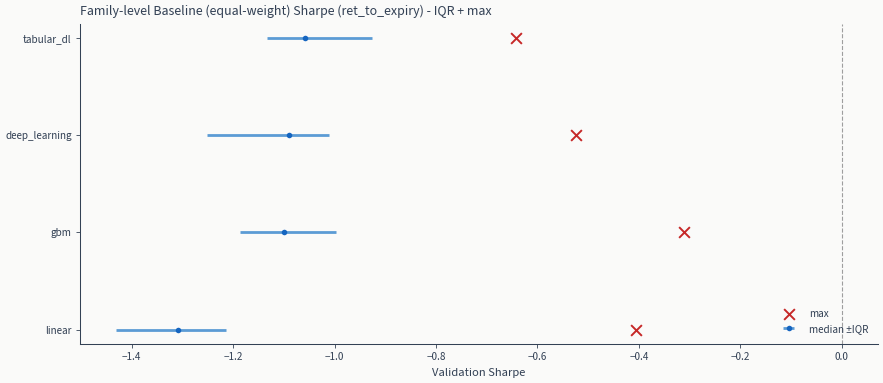

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    label="median ±IQR",
)
ax.scatter(maxima, y, marker="x", color="#C62828", s=60, label="max", zorder=5)
ax.axvline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
ax.set_title("Family-level Baseline (equal-weight) Sharpe (ret_to_expiry) - IQR + max")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.show()

Three families produce zero positive-Sharpe baseline rows on `ret_to_expiry`.
Linear has two near-zero nonnegative rows among the complete baseline surface.
The full-universe leader is comparison evidence only; the registered carrier
is the liquid-universe rank-1. Neither resolves a statistically reliable edge.

In [18]:
# Lineage stages for the registered HTM rank-1
print(f"Lineage stages registered against prediction {TOP_PHASH} (HTM rank-1):")
with sqlite3.connect(str(_db)) as _con:
    rows = _con.execute(
        """
        SELECT b.stage, COUNT(*) AS n
        FROM backtest_runs b
        WHERE b.prediction_hash = ?
        GROUP BY b.stage
        """,
        (TOP_PHASH,),
    ).fetchall()
    for stage, n in rows:
        print(f"  {stage}: {n} runs")

print()
print(
    "All ret_to_expiry backtests route through the HTM daily-MTM cohort "
    "engine (`_run_htm_daily_mtm`). The equal-weight baseline selects the top-K "
    "cross-section (eq_w_topk); the allocation stage overlays a within-"
    "cross-section weighting on the HTM cohort accounting; the risk_overlay "
    "stage layers position-level controls on top of the allocator weights. "
    "The cost sweep lives in `15_costs`, in fractions of the quoted "
    "half-spread (the standard bps cost-grid is the wrong unit for option "
    "premium returns)."
)

Lineage stages registered against prediction 33eea3466646 (HTM rank-1):
  allocation: 6 runs
  cost_sensitivity: 8 runs
  signal: 3 runs

All ret_to_expiry backtests route through the HTM daily-MTM cohort engine (`_run_htm_daily_mtm`). The equal-weight baseline selects the top-K cross-section (eq_w_topk); the allocation stage overlays a within-cross-section weighting on the HTM cohort accounting; the risk_overlay stage layers position-level controls on top of the allocator weights. The cost sweep lives in `15_costs`, in fractions of the quoted half-spread (the standard bps cost-grid is the wrong unit for option premium returns).


## §3 Headline performance with uncertainty

The pinned carrier's performance metrics use 95% block-bootstrap CIs.
Selection-bias adjustment (DSR raw / MP / ER, k_variants,
expected_max_sharpe, min_trl_periods) lives in `cohort_metrics` per
`memory/UNCERTAINTY_ARCHITECTURE.md` - `backtest_metrics` no longer
carries those columns. The DSR uses the complete cross-family baseline
cohort and names its full-universe leader. That leader differs from the pinned
liquid carrier, so these statistics are not presented as carrier metrics.
Linear-family PBO is displayed separately and suppressed because only two
CSCV combinations are available. ER is the maintainer-recommended default;
raw and MP are recorded for context.

In [19]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": PRIMARY_LABEL,
    "stage": _lineage["val_stage"],
    "signal_method": "equal_weight_top_k",
    "allocator": ALLOCATOR_METHOD,
    "top_k": 5,
    "universe_filter": UNIVERSE_FILTER,
    "cascade_rung": CASCADE_RUNG,
    "rebalance_cadence": setup["decision"]["entry_cadence"],
    "rebalance_step_weeks": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
    "hedge_cadence": setup["decision"]["hedge_cadence"],
    "exit_rule": setup["decision"]["exit_time"],
    "cost_model": "HTM daily-MTM cohort: option entry spread + daily underlying hedge spread + commissions",
    "cumulative_entry_cost_premium_units": full["cumulative_entry_cost"],
    "cumulative_hedge_cost_premium_units": full["cumulative_hedge_cost"],
    "n_rebalance_dates": int(full["n_rebalance_dates"])
    if full["n_rebalance_dates"] is not None
    else None,
    "avg_cohorts_open": full["avg_cohorts_open"],
    "validation_window_periods": int(full["n_periods"]),
    "bootstrap_block_length": int(full["bootstrap_block_length"]),
    "bootstrap_n": int(full["bootstrap_n"]),
}
print("Pinned-carrier specification (equal-weight baseline, validation window):")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

Pinned-carrier specification (equal-weight baseline, validation window):
  case_study: sp500_options
  family: linear
  config_name: lasso_f0.7
  label: ret_to_expiry
  stage: allocation
  signal_method: equal_weight_top_k
  allocator: hrp
  top_k: 5
  universe_filter: liquid
  cascade_rung: 3
  rebalance_cadence: weekly_friday
  rebalance_step_weeks: 5
  hedge_cadence: daily_close
  exit_rule: 10_days_after_entry_or_expiry
  cost_model: HTM daily-MTM cohort: option entry spread + daily underlying hedge spread + commissions
  cumulative_entry_cost_premium_units: 0.7961624745743429
  cumulative_hedge_cost_premium_units: 0.10479258223170075
  n_rebalance_dates: 96
  avg_cohorts_open: 4.833333333333333
  validation_window_periods: 462
  bootstrap_block_length: 5
  bootstrap_n: 1000


Format one uncertainty row consistently across the headline table.

In [20]:
def _row(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}

Collect the carrier's bootstrap intervals before adding the
selection-adjusted diagnostics.

In [21]:
sharpe_status = ci_status(full["sharpe_ci95_lo"], full["sharpe_ci95_hi"])
sortino_status = ci_status(full["sortino_ci95_lo"], full["sortino_ci95_hi"])
ann_status = ci_status(full["ann_return_ci95_lo"], full["ann_return_ci95_hi"])
mdd_status = ci_status(full["max_dd_ci95_lo"], full["max_dd_ci95_hi"])
calmar_status = ci_status(full["calmar_ci95_lo"], full["calmar_ci95_hi"])
metric_specs = [
    ("Sharpe", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi", sharpe_status),
    ("Sortino", "sortino", "sortino_ci95_lo", "sortino_ci95_hi", sortino_status),
    ("Annualized return", "cagr", "ann_return_ci95_lo", "ann_return_ci95_hi", ann_status),
    ("Max drawdown", "max_drawdown", "max_dd_ci95_lo", "max_dd_ci95_hi", mdd_status),
    ("Calmar", "calmar", "calmar_ci95_lo", "calmar_ci95_hi", calmar_status),
]
performance_rows = [
    _row(label, _fmt(full[point]), _fmt(full[lo]), _fmt(full[hi]), status)
    for label, point, lo, hi, status in metric_specs
]
performance_rows.append(_row("PSR p-value (H0: SR≤0)", _fmt(full["psr_pvalue"]), "-", "-", "n/a"))

Attribute each DSR variant to the exact cross-family cohort and keep
the insufficient family PBO visibly separate.

In [22]:
dsr_rows = []
for suffix, label in [("raw", "DSR_raw"), ("er", "DSR_ER"), ("mp", "DSR_MP")]:
    pvalue = SEARCH_COHORT[f"dsr_{suffix}_pvalue"]
    status = f"{suffix}_p={pvalue:.3f}" if pvalue is not None else "cohort_unavailable"
    dsr_rows.append(
        _row(
            f"{label} (baseline leader {SEARCH_COHORT['leader_hash']})",
            _fmt(SEARCH_COHORT[f"dsr_{suffix}"]),
            "-",
            "-",
            status,
        )
    )

diagnostic_rows = [
    _row(
        "PBO (linear-family cohort)",
        _fmt(PBO_REPORT["value"]) if PBO_REPORT["value"] is not None else "insufficient",
        "-",
        "-",
        PBO_REPORT["status"],
    ),
    _row(
        "k_variants (cross-family search cohort)",
        str(int(SEARCH_COHORT["k_variants"])),
        "-",
        "-",
        "n/a",
    ),
]

Display the performance and selection diagnostics in one compact table.

In [23]:
headline = pl.DataFrame(performance_rows + dsr_rows + diagnostic_rows)
print("Current-carrier performance and exactly attributed search diagnostics:")
print(headline)

Current-carrier performance and exactly attributed search diagnostics:
shape: (11, 5)
┌────────────────────────────┬──────────────┬─────────┬─────────┬──────────────────────────────────┐
│ metric                     ┆ point        ┆ ci95_lo ┆ ci95_hi ┆ status                           │
│ ---                        ┆ ---          ┆ ---     ┆ ---     ┆ ---                              │
│ str                        ┆ str          ┆ str     ┆ str     ┆ str                              │
╞════════════════════════════╪══════════════╪═════════╪═════════╪══════════════════════════════════╡
│ Sharpe                     ┆ -0.2083      ┆ -1.7870 ┆ 1.5297  ┆ straddles_zero                   │
│ Sortino                    ┆ -0.2503      ┆ -2.0423 ┆ 2.0049  ┆ straddles_zero                   │
│ Annualized return          ┆ -0.2631      ┆ -0.7480 ┆ 0.9317  ┆ straddles_zero                   │
│ Max drawdown               ┆ -0.8549      ┆ -0.9537 ┆ -0.3593 ┆ excludes_zero_strong             │
│ Cal

The cross-family DSR row has K equal to the registered baseline count and names
the complete-grid baseline
leader, not the pinned liquid carrier. PBO is a separate linear-family
diagnostic. With only two CSCV combinations, the notebook reports
"insufficient combinations" instead of interpreting 0.50.

In [24]:
# Prepare the rank-1 metric stack and reference benchmark for a forest plot.
ew_val = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="validation")
ew_ho = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="holdout")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
    ("Ann. return", full["cagr"], full["ann_return_ci95_lo"], full["ann_return_ci95_hi"]),
]

Plot the carrier intervals against zero and the validation equal-weight
benchmark.

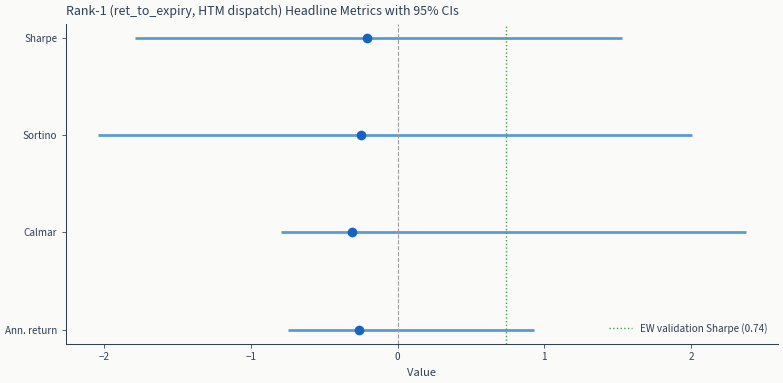

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.errorbar(
    points,
    y,
    xerr=[points - los, his - points],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    markersize=7,
)
ax.axvline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.axvline(
    ew_val["sharpe"],
    color="#43A047",
    linestyle=":",
    linewidth=1.0,
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Value")
ax.set_title("Rank-1 (ret_to_expiry, HTM dispatch) Headline Metrics with 95% CIs")
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

Validation overlay window: 2019-01-14 → 2020-11-10, n=462


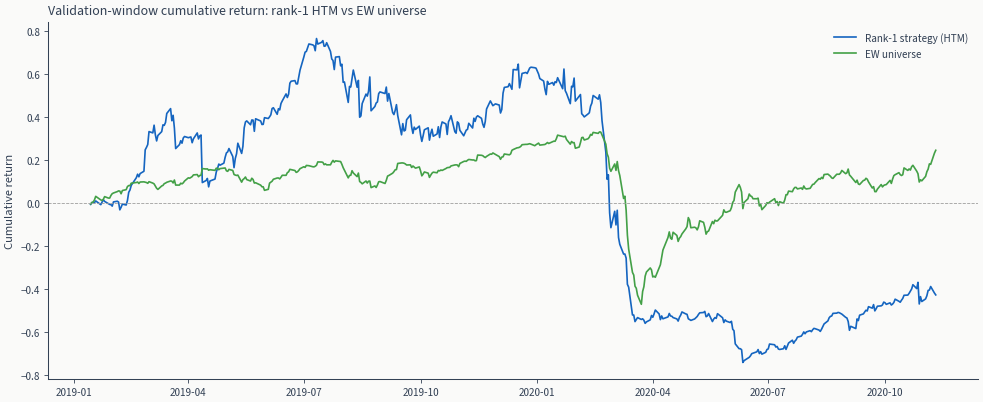

In [26]:
# Equity-curve overlay vs validation EW benchmark
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, PRIMARY_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("ew_return").alias("benchmark"))
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

cum_strat = np.cumprod(1 + aligned["strategy"].to_numpy()) - 1
cum_bench = np.cumprod(1 + aligned["benchmark"].to_numpy()) - 1
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(aligned["ts"], cum_strat, color="#1565C0", linewidth=1.2, label="Rank-1 strategy (HTM)")
ax.plot(aligned["ts"], cum_bench, color="#43A047", linewidth=1.2, label="EW universe")
ax.axhline(0, color="#9E9E9E", linewidth=0.6, linestyle="--")
ax.set_ylabel("Cumulative return")
ax.set_title("Validation-window cumulative return: rank-1 HTM vs EW universe")
ax.legend(loc="best", frameon=False)
fig.tight_layout()
fig.show()

The validation Sharpe straddles zero with a CI that spans roughly ±1
Sharpe in either direction - the validation window does not resolve a
directional edge for this strategy. Sortino, Calmar, and Ann. return
all sit in the same straddles_zero status; PSR confirms the read.
Whichever side of zero the point estimate falls on, the validation
evidence is null-consistent. § 6's paired holdout vs EW test resolves
whether the validation/EW gap holds out of sample. Selection accounting
is supplied by the exact cross-family baseline cohort above (DSR raw /
MP / ER and K from `cohort_metrics`), whose named leader differs from
the carrier. Linear-family PBO is separately suppressed as underidentified.
The two near-zero nonnegative baseline rows do not alter the unresolved
selection-adjusted DSR_ER reading.

## §3a Label scope and prior diagnostic exhibit

The equal-weight baseline sweep on this case study now runs on a single label
- `ret_to_expiry` - under HTM cost accounting (entry-side option
spread + daily underlying hedge spread, plus an exit-leg option trade only
where a contract's chain ends before its expiration date).
Four legacy diagnostic labels (`fwd_ret_5d`, `fwd_ret_10d`,
`fwd_ret_dh_5d`, `fwd_ret_dh_10d`) were dropped from the sweep on
2026-05-17: they routed through the vectorized backtest path that
treats 5d/10d forward returns as daily returns, inflating Sharpes
to non-credible levels.
The structural diagnostic remains valid as prose: equity-style
bps-of-notional cost accounting understates option spread cost by
1-2 orders of magnitude versus the actual % of premium, so any
equity-style backtester on option premium returns produces
pathological CAGR / drawdown numerics. The registered strategy
therefore uses HTM cost accounting on `ret_to_expiry`, and under
that accounting the cross-section does not resolve a statistically
significant edge on the validation window.

## §4 Risk and drawdown analysis

The validation-window strategy returns paired against the validation
EW benchmark. Tail-risk metrics come from the registry directly; the
fold breakdown surfaces the across-fold dispersion that drives the
bootstrap CI's width.

In [27]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
print(dd)

Drawdown analysis (validation window):
DrawdownResult(current_drawdown=-0.6765709657132232, max_drawdown=-0.8548919248450312, avg_drawdown=-0.40038144110735296, underwater_curve=shape: (462,)
Series: 'drawdown' [f64]
[
	0.0
	0.0
	0.0
	-0.001181
	0.0
	…
	-0.664707
	-0.663797
	-0.654435
	-0.6718
	-0.676571
], top_drawdowns=[DrawdownPeriod(peak_date=datetime.date(2019, 7, 11), valley_date=datetime.date(2020, 6, 11), recovery_date=None, depth=np.float64(-0.8548919248450312), duration_days=232, recovery_days=None), DrawdownPeriod(peak_date=datetime.date(2019, 3, 18), valley_date=datetime.date(2019, 4, 17), recovery_date=datetime.date(2019, 6, 6), depth=np.float64(-0.2533723223722549), duration_days=22, recovery_days=34), DrawdownPeriod(peak_date=datetime.date(2019, 3, 5), valley_date=datetime.date(2019, 3, 7), recovery_date=datetime.date(2019, 3, 12), depth=np.float64(-0.053896087726797604), duration_days=2, recovery_days=3), DrawdownPeriod(peak_date=datetime.date(2019, 1, 24), valley_date=

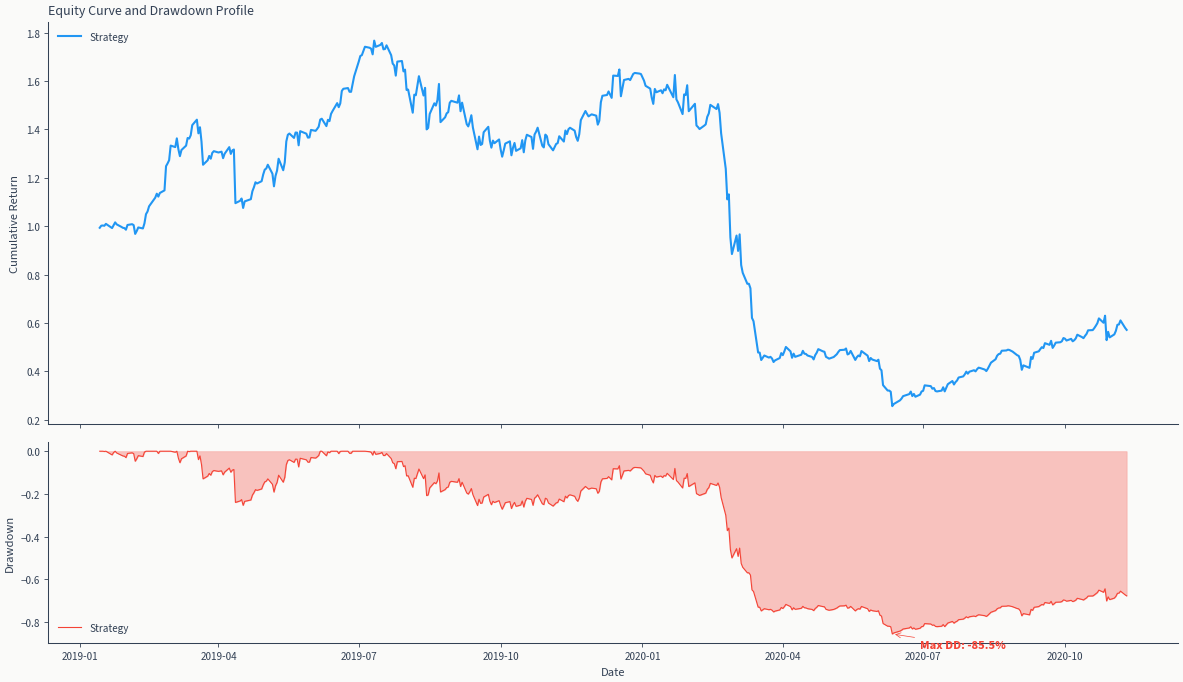

In [28]:
fig = plot_equity_drawdown(strat_returns_path)
fig.show()

In [29]:
roll = pa.compute_rolling_metrics(windows=[126], metrics=["sharpe", "beta"])
if isinstance(roll, dict):
    print("Rolling-window keys:")
    print({k: type(v).__name__ for k, v in roll.items()})

tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (daily)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (daily)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)


Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.5892  │
│ VaR 95% (daily)   ┆ -0.0620 │
│ CVaR 95% (daily)  ┆ -0.1084 │
│ Tail ratio        ┆ 0.708   │
│ Skewness          ┆ -1.814  │
│ Kurtosis          ┆ 6.653   │
└───────────────────┴─────────┘


In [30]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
print(f"Per-fold breakdown ({fold_df.height} folds):")
print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))
print()
if fold_df.height > 1:
    print(f"Fold Sharpe range: [{fold_df['sharpe'].min():.3f}, {fold_df['sharpe'].max():.3f}]")
    print(f"Fold Sharpe std:   {fold_df['sharpe'].std():.3f}")

Per-fold breakdown (2 folds):
shape: (2, 4)
┌─────────┬───────────┬──────────────┬────────┐
│ fold_id ┆ sharpe    ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---       ┆ ---          ┆ ---    │
│ i64     ┆ f64       ┆ f64          ┆ f64    │
╞═════════╪═══════════╪══════════════╪════════╡
│ 0       ┆ -1.272335 ┆ -0.842197    ┆ 216.0  │
│ 1       ┆ 1.282042  ┆ -0.271507    ┆ 246.0  │
└─────────┴───────────┴──────────────┴────────┘

Fold Sharpe range: [-1.272, 1.282]
Fold Sharpe std:   1.806


The two fold Sharpes straddle zero and both sit inside the wide
bootstrap Sharpe CI in Section 3. Tail risk is heavy: negative skew
and high kurtosis reflect the asymmetric P&L profile
of a short straddle book - long stretches of small premium decay
punctuated by large losses when realized vol exceeds implied.
CVaR and max drawdown are severe, the defining signature
of the strategy: even with hedging and HTM settlement, a single
bad-vol regime can wipe out cumulative premium.

## §5 Friction budget

The standard `BacktestExplorer.cost_sensitivity()` curve is denominated in bps per leg, which is
the right convention for equities and futures but the wrong unit for options: a 10% spread on a
4% premium is 40 bps of notional, well inside the "positive Sharpe" zone of any equity sweep and
ruinous for the actual P&L. `15_costs` runs the cost sweep in fractions of the quoted half-spread
instead, executes it through the same engine as every other backtest, and publishes it as the
named population `sp500-options-cost-sensitivity-validation-v1`. It reports the resulting Sharpe
surface across families, universes and spread fractions there, each point with its
block-bootstrap Sharpe interval, so this notebook does not repeat it.

## §6 Holdout closure with paired bootstrap

Two paired tests anchor the holdout read. (i) The holdout rank-1
versus the validation rank-1 ("did Sharpe hold?"); (ii) the holdout
rank-1 versus the holdout-window equal-weight benchmark ("did the
strategy beat random in the holdout?"). Numbers come from
`backtest_paired_metrics` rows populated for this fixed case lineage;
never from val_sharpe minus holdout_sharpe arithmetic.

In [31]:
ho_full = load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)
val_full = full

print(f"Validation rank-1 hash: {TOP_HASH} (Sharpe {val_full['sharpe']:+.4f})")
print(f"Holdout rank-1 hash:    {HO_HASH} (Sharpe {ho_full['sharpe']:+.4f})")
print()
print(
    f"Holdout window: {setup['evaluation']['holdout_start']} → {setup['evaluation']['holdout_end']}"
)
print(f"Holdout n_periods: {int(ho_full['n_periods'])}")

Validation rank-1 hash: de9af2fca1cd (Sharpe -0.2083)
Holdout rank-1 hash:    c363cd4ed786 (Sharpe +1.2683)

Holdout window: 2021-01-01 → 2021-12-31
Holdout n_periods: 247


In [32]:
val_ho_pair = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="val_rank1_self",
)
if val_ho_pair.is_empty():
    raise RuntimeError(
        "Missing required val_rank1_self paired metrics for current holdout "
        f"{HO_HASH}; populate this case before executing notebook 16"
    )
vh = val_ho_pair.row(0, named=True)

Format one paired validation-to-holdout metric, preserving its
bootstrap interval and p-value when available.

In [33]:
def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f"),
        "holdout": _fmt(h, ".4f"),
        "diff (h−v)": _fmt(diff, ".4f") if diff is not None else "-",
        "diff CI95": f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "-",
        "p-value": _fmt(p, ".4f") if p is not None else "-",
    }

Build the disjoint-window comparison from the stored paired-bootstrap
row rather than subtracting headline metrics.

In [34]:
pair_specs = [
    ("Sharpe", "sharpe", "sharpe_diff", "sharpe_diff_ci95", "p_value"),
    ("Annualized return", "cagr", "ret_diff", "ret_diff_ci95", None),
    ("Max drawdown", "max_drawdown", "max_dd_diff", "max_dd_diff_ci95", None),
]
pair_rows = [
    _diff_row(
        label,
        val_full[metric],
        ho_full[metric],
        vh[diff],
        vh[f"{ci_prefix}_lo"],
        vh[f"{ci_prefix}_hi"],
        vh[pvalue] if pvalue else None,
    )
    for label, metric, diff, ci_prefix, pvalue in pair_specs
]
pair_rows.append(
    _diff_row(
        "Information ratio",
        None,
        None,
        vh["info_ratio"],
        vh["info_ratio_ci95_lo"],
        vh["info_ratio_ci95_hi"],
        None,
    )
)
val_ho_table = pl.DataFrame(pair_rows)

Display the paired decay statistics and state the disjoint-window
bootstrap construction.

In [35]:
print("val → holdout paired-bootstrap decay (rank-1 self):")
print(val_ho_table)
print(
    "prob_challenger_wins: "
    + (f"{vh['prob_challenger_wins']:.3f}" if vh["prob_challenger_wins"] is not None else "-")
)
print(f"CI status (Sharpe diff): {ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}")
print()
print(
    "Note: validation and holdout windows are disjoint. The paired-metrics "
    "producer therefore uses independent stationary block-bootstrap draws "
    "for the two windows rather than calendar alignment."
)

val → holdout paired-bootstrap decay (rank-1 self):
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬───────────────────┬─────────┐
│ metric            ┆ validation ┆ holdout ┆ diff (h−v) ┆ diff CI95         ┆ p-value │
│ ---               ┆ ---        ┆ ---     ┆ ---        ┆ ---               ┆ ---     │
│ str               ┆ str        ┆ str     ┆ str        ┆ str               ┆ str     │
╞═══════════════════╪════════════╪═════════╪════════════╪═══════════════════╪═════════╡
│ Sharpe            ┆ -0.2083    ┆ 1.2683  ┆ 1.4766     ┆ [-0.9861, 3.8542] ┆ 0.2545  │
│ Annualized return ┆ -0.2631    ┆ 0.5552  ┆ 0.8183     ┆ [-0.6162, 2.4666] ┆ -       │
│ Max drawdown      ┆ -0.8549    ┆ -0.2653 ┆ 0.5896     ┆ [0.0301, 0.7446]  ┆ -       │
│ Information ratio ┆ -          ┆ -       ┆ -          ┆ -                 ┆ -       │
└───────────────────┴────────────┴─────────┴────────────┴───────────────────┴─────────┘
prob_challenger_wins: 0.864
CI status (Sharpe diff): s

In [36]:
ho_vs_ew = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="equal_weight_holdout_side_artifact",
)
if ho_vs_ew.is_empty():
    raise RuntimeError(
        "Missing required equal_weight_holdout_side_artifact paired metrics for "
        f"current holdout {HO_HASH}; populate this case before executing notebook 16"
    )
he = ho_vs_ew.row(0, named=True)

print("Holdout strategy vs holdout-window EW universe:")
print(f"  strategy Sharpe:  {ho_full['sharpe']:+.4f}")
print(f"  EW Sharpe:        {ew_ho['sharpe']:+.4f}")
print(
    "  diff Sharpe: "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'], '.4f')}"
)
print("  p_value:                " + (f"{he['p_value']:.4f}" if he["p_value"] is not None else "-"))
print(
    "  prob_challenger_wins:   "
    + (f"{he['prob_challenger_wins']:.3f}" if he["prob_challenger_wins"] is not None else "-")
)
print(
    f"  info_ratio (strategy vs EW): "
    f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
)
print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

Holdout strategy vs holdout-window EW universe:
  strategy Sharpe:  +1.2683
  EW Sharpe:        +2.7137
  diff Sharpe: -1.2791 [-3.2038, 0.6525]
  p_value:                0.2040
  prob_challenger_wins:   0.111
  info_ratio (strategy vs EW): 0.366 [-1.374, 2.172]
  CI status: straddles_zero


**Reading.** The two paired tables above are the authoritative holdout
evidence for the fixed current carrier. Point-estimate ordering alone
does not establish persistence or benchmark superiority; the paired
confidence intervals and p-values determine whether either difference
is resolved. The 2021 window is reported once and is not reused for
model or strategy selection.

## §7 Benchmark-aware diagnostics

Layer 1 reports the universal alpha/beta/IR profile via
`PortfolioAnalysis` against the equal-weight S&P 500 options universe.
Layer 2 - equity factor attribution (FF5+MOM) - is in scope per the
case-study scope deviation table for equity-class case studies, but the model
fit is structurally compromised on options: FF5+MOM captures linear
equity factor exposure, while option premium returns are driven by
vega, gamma, and theta - non-linear payoffs that are orthogonal to
linear factor loadings. We include the regression for completeness
but flag the model mismatch in the reading.

In [37]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):")
print(attr_df)

Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):
shape: (6, 2)
┌────────────────────┬─────────┐
│ metric             ┆ value   │
│ ---                ┆ ---     │
│ str                ┆ str     │
╞════════════════════╪═════════╡
│ alpha (annualized) ┆ -0.2419 │
│ beta               ┆ 0.693   │
│ information ratio  ┆ -0.5313 │
│ tracking error     ┆ -       │
│ up capture         ┆ 0.3170  │
│ down capture       ┆ 1.4472  │
└────────────────────┴─────────┘


In [38]:
# Placebo regression: residual α and HAC t-stat on EW alone.
import statsmodels.api as sm

X = sm.add_constant(bench_arr)
ols = sm.OLS(strat_arr, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_daily = ols.params[0]
alpha_t = ols.tvalues[0]
alpha_p = ols.pvalues[0]
beta_ew = ols.params[1]
beta_t = ols.tvalues[1]
print()
print("Placebo regression vs EW universe (HAC, maxlags=5):")
print(f"  α (daily) = {alpha_daily:.6f}, α (annualized) = {alpha_daily * PERIODS_PER_YEAR:.4f}")
print(f"  α t-stat = {alpha_t:.3f}, p = {alpha_p:.3f}")
print(f"  β        = {beta_ew:.3f}, β t-stat = {beta_t:.3f}")
print(f"  CI status (α): {'excludes_zero_strong' if alpha_p < 0.05 else 'straddles_zero'}")


Placebo regression vs EW universe (HAC, maxlags=5):
  α (daily) = -0.000960, α (annualized) = -0.2419
  α t-stat = -0.567, p = 0.570
  β        = 0.693, β t-stat = 3.443
  CI status (α): straddles_zero


In [39]:
# Layer 2: FF5+MOM factor regression with HAC standard errors.
strategy_rets_pd = pd.Series(
    strat_arr,
    index=pd.to_datetime(aligned["ts"].to_list()),
    name="strategy",
)
_period_start = str(strategy_rets_pd.index.min().date())
_period_end = str(strategy_rets_pd.index.max().date())

_factors = load_factor_data(start=_period_start, end=_period_end)
_reg = run_factor_regression(
    strategy_rets_pd,
    _factors,
    model="ff5_mom",
    hac_lags=5,
    dollar_neutral=False,
)

print()
print("Layer 2: FF5+MOM factor attribution (HAC, daily):")
print(f"  n_obs:           {_reg['n_obs']}")
print(f"  R²:              {_reg['r_squared']:.3f}")
print(
    f"  α (annualized):  {_reg['alpha_annualized']:+.4f}  "
    f"(t={_reg['alpha_t_stat']:.2f}, p={_reg['alpha_p_value']:.3f})"
)
print(f"  Strategy Sharpe: {_reg['strategy_sharpe']:+.3f}")
print(f"  Residual Sharpe: {_reg['residual_sharpe']:+.3f}")
print()
print("Factor betas (HAC):")
for factor, beta in _reg["betas"].items():
    t = _reg["t_stats"][factor]
    sig = "*" if _reg["p_values"][factor] < 0.05 else ""
    print(f"  {factor:8s}: {beta:+.4f}  (t={t:+.2f}){sig}")


Layer 2: FF5+MOM factor attribution (HAC, daily):
  n_obs:           462
  R²:              0.276
  α (annualized):  -0.4127  (t=-0.96, p=0.339)
  Strategy Sharpe: -0.237
  Residual Sharpe: -0.824

Factor betas (HAC):
  Mkt-RF  : +1.1680  (t=+5.71)*
  SMB     : +0.1056  (t=+0.36)
  HML     : -0.5214  (t=-1.82)
  RMW     : -0.8563  (t=-2.10)*
  CMA     : +0.9283  (t=+1.67)
  MOM     : +0.2463  (t=+1.02)


In [40]:
# Block bootstrap CIs on alpha and factor betas
_boot = compute_bootstrap_ci(
    strategy_rets_pd,
    _factors,
    model="ff5_mom",
    n_boot=500,
    block_size=20,
    dollar_neutral=False,
    seed=42,
)

if _boot.get("n_boot", 0) > 0:
    print(f"\nBootstrap CIs (n={_boot['n_boot']}, block=20 days):")
    print(
        f"  α (annualized): [{_boot['alpha_ann_lo']:+.4f}, {_boot['alpha_ann_hi']:+.4f}] (95% CI)"
    )
    for factor in _reg["factor_columns"]:
        key_lo = f"{factor}_lo"
        key_hi = f"{factor}_hi"
        if key_lo in _boot:
            print(f"  {factor:8s}: [{_boot[key_lo]:+.4f}, {_boot[key_hi]:+.4f}]")


Bootstrap CIs (n=500, block=20 days):
  α (annualized): [-1.5254, +0.5502] (95% CI)
  Mkt-RF  : [+0.7391, +2.0026]
  SMB     : [-0.5771, +0.5480]
  HML     : [-0.9966, +0.5543]
  RMW     : [-1.6401, -0.1375]
  CMA     : [-0.0530, +1.9963]
  MOM     : [-0.1989, +1.0130]


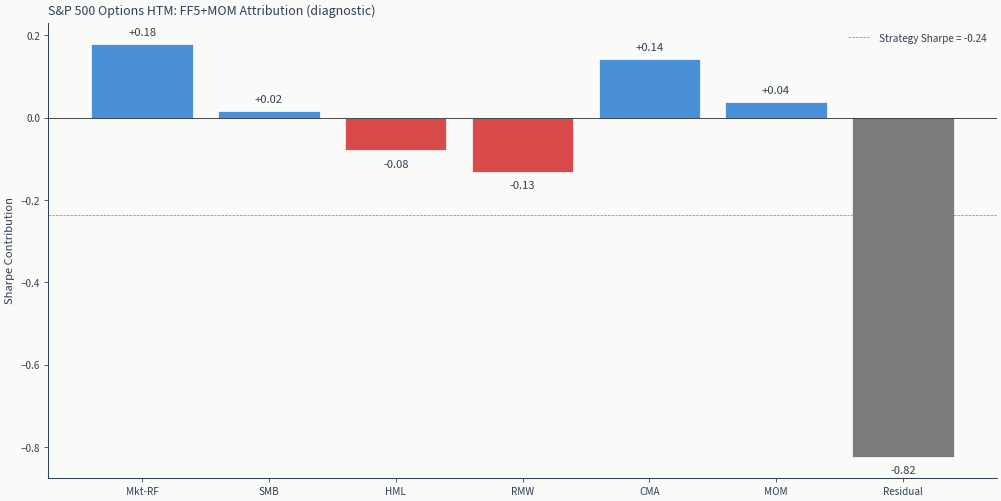

In [41]:
fig_attr = plot_attribution_waterfall(
    _reg, title="S&P 500 Options HTM: FF5+MOM Attribution (diagnostic)"
)
fig_attr.show()

Layer-1 placebo regression vs EW: α (annualized) and HAC t-stat read
directly off the print block above. Layer-2 FF5+MOM produces a low R²
by design - the linear factor model captures whatever residual equity
delta leaks through the daily delta hedge, but the dominant return
drivers (gamma, vega, theta) sit outside the FF5+MOM linear span.
The α point estimate is therefore not interpretable as
"factor-adjusted edge" for an options strategy in the same sense as
for an equity portfolio; it's a residual after a structurally
incomplete factor model. The diagnostic value is in the *betas*: a
significant Mkt-RF loading would indicate incomplete delta hedging
(the daily rehedge with a 0.10 net-delta band leaks some directional
exposure); a significant MOM loading would suggest the model selects
straddles on names whose option markets lag equity momentum (a
microstructure artefact).

A volatility-native attribution (VIX, VVIX, term-structure slope,
variance risk premium factors) is the right model for this strategy.
That construction is a Ch20 extension (the dispersion-trading
literature provides it); per strategy-analysis convention this notebook reports
what's available without synthesizing a new factor model inline.

## §8 Strategy tear sheet

The diagnostic library renders the rank-1 lineage's tear sheet
directly from the on-disk artefacts. The HTM dispatch writes
`daily_returns.parquet` and `weights.parquet` but no
`trades.parquet` - the bridge layer reconstructs trade-level surfaces
where it can; otherwise the tear sheet's reconstructed-availability
flags propagate to the prose. Per case-study scope deviation, sp500_options uses
`template="full"`.

In [42]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
trades_present = (backtest_dir / "trades.parquet").exists()
print(f"Validation backtest_dir: {backtest_dir}")
print(f"  trades.parquet present:   {trades_present}")
print(f"  daily_returns.parquet:    {(backtest_dir / 'daily_returns.parquet').exists()}")
print(f"  weights.parquet:          {(backtest_dir / 'weights.parquet').exists()}")
print()
print(
    "HTM daily-MTM dispatch does not emit per-trade fills; tear sheet trade "
    "surfaces are reconstructed by the bridge layer where it can do so. "
    "Reconstructed-availability flags propagate to the rendered tear sheet."
)

Validation backtest_dir: ~/ml4t/public-s6-sp500_options/case_studies/sp500_options/run_log/backtest/de9af2fca1cd
  trades.parquet present:   False
  daily_returns.parquet:    True
  weights.parquet:          True

HTM daily-MTM dispatch does not emit per-trade fills; tear sheet trade surfaces are reconstructed by the bridge layer where it can do so. Reconstructed-availability flags propagate to the rendered tear sheet.


In [43]:
# Render the full tear sheet only when the HTM artefacts include fills.
if trades_present:
    bench_series = bench_val.rename({"benchmark": "ew_return"})["ew_return"].to_numpy()
    meta = BacktestReportMetadata(
        title="S&P 500 Options - Rank-1 Lineage (HTM dispatch)",
        strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} - {PRIMARY_LABEL} (HTM, allocator={ALLOCATOR_METHOD})",
        universe="S&P 500 constituents - ATM straddles, final session of each Friday week",
        benchmark_name="EW universe (validation)",
        evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
        calendar=setup["evaluation"]["calendar"],
    )
    tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
    html = generate_tearsheet_from_run_artifacts(
        backtest_dir,
        template="full",
        benchmark=bench_series,
        benchmark_name="EW universe (validation)",
        calendar=setup["evaluation"]["calendar"],
        report_metadata=meta,
        output_path=str(tear_path),
    )
    print(f"Tear sheet written to: {tear_path}")
    print(f"HTML size: {len(html):,} bytes")
    tear_status = "rendered"
else:
    print(
        "Tear sheet skipped - HTM dispatch does not emit per-trade fills, and "
        "the bridge layer requires trades.parquet to reconstruct the tear "
        "sheet's trade surfaces. No trades are synthesized. Equivalent surfaces are covered by "
        "the rendered §3 forest plot, §4 drawdown panel, §6 paired holdout "
        "test, and §7 factor attribution."
    )
    tear_status = "skipped_no_trades"

Tear sheet skipped - HTM dispatch does not emit per-trade fills, and the bridge layer requires trades.parquet to reconstruct the tear sheet's trade surfaces. No trades are synthesized. Equivalent surfaces are covered by the rendered §3 forest plot, §4 drawdown panel, §6 paired holdout test, and §7 factor attribution.


## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside sp500_options - cross-case-study comparison
is Ch20's lane.

In [44]:
# Operating profile from the (signal-only) lineage.
lineage = {
    "signal": {
        "sharpe": full["sharpe"],
        "cagr": full["cagr"],
        "max_drawdown": full["max_drawdown"],
        "volatility": full["volatility"],
        "total_return": full["total_return"],
        "backtest_hash": TOP_HASH,
        "signal_method": "equal_weight_top_k",
        "top_k": 5,
    }
}
op_profile = compute_operating_profile(lineage, setup)
op_profile = op_profile.with_columns(
    pl.when(pl.col("property") == "Trading cadence")
    .then(pl.lit(setup["decision"]["entry_cadence"]))
    .otherwise(pl.col("value"))
    .alias("value")
)
print("Operating profile (sp500_options HTM, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt_ci(getattr(metrics, 'information_ratio', None), None, None)}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (sp500_options HTM, validation window):
shape: (5, 2)
┌─────────────────────────────────┬───────────────┐
│ property                        ┆ value         │
│ ---                             ┆ ---           │
│ str                             ┆ str           │
╞═════════════════════════════════╪═══════════════╡
│ Trading cadence                 ┆ weekly_friday │
│ Portfolio concentration (top_k… ┆ -             │
│ Allocator                       ┆ -             │
│ Cost assumption                 ┆ -             │
│ Worst drawdown                  ┆ -85.5%        │
└─────────────────────────────────┴───────────────┘

Sharpe: -0.208 [-1.787, 1.530]
Info ratio (vs EW val): -0.531 [-, -]
Max drawdown: -0.855


In [45]:
# Kill-condition gates (universal - see §1)
gate1_lo = val_full["sharpe_ci95_lo"]
gate1_status = gate1_validation_sharpe_geq_zero(gate1_lo)
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = f"Sharpe CI lower bound = {_fmt(gate1_lo, '.3f')} ({_gate1_phrase})"
gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(gate2_ci_status, he["sharpe_diff"])
gate2_evidence = (
    f"Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [FAIL] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = -1.787 (< 0 (fails))
  [PASS] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = -1.279 [-3.204, 0.652] (straddles_zero)


**What this analysis does not say.** The sp500_options holdout window
covers calendar-year 2021, a single period in which the equal-weight
straddle universe may represent an unusually favorable regime.
The holdout is too short and too regime-specific to support
conclusions about long-run behavior; the wide val→ho diff CI reflects
that small-sample regime more than long-run uncertainty. Selection
accounting lives in `cohort_metrics` per
`memory/UNCERTAINTY_ARCHITECTURE.md`: DSR raw / MP / ER, PBO,
k_variants, expected_max_sharpe, and min_trl_periods are queried from
the exact cross-family cohort (equal-weight baseline, ret_to_expiry)
and reported in Section 3 under its own leader's identity. The
separate linear-family PBO is suppressed because it has only two CSCV
combinations. The two near-zero nonnegative rows remain consistent with
the unresolved cohort-level DSR_ER reading.
Layer-2 factor
attribution uses FF5+MOM, which is structurally incomplete for a
short-vol strategy - gamma, vega, and theta exposures are not in the
linear span of those factors. A volatility-native attribution
(VIX/VVIX/term-structure/VRP) is the right model and lives in Ch20.
The kill conditions encoded in `setup.yaml`
(vrp_compression / gamma_loss_dominance / cost_erosion) are not
evaluated by a registry-only read; the universal CI gates substitute
for them in this notebook.

**Forward pointer to Ch20.** This case study contributes the
equity-options HTM datapoint to Ch20 nb04's cost-survival
comparison; the §6 holdout-strategy-vs-EW-benchmark reading
feeds Ch20 nb05's decay-classification table after the case record is
frozen.

Encode the accepted carrier identity and operating specification.

In [46]:
rank1_assessment = {
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": PRIMARY_LABEL,
    "stage": _lineage["val_stage"],
    "prediction_hash": TOP_PHASH,
    "validation_backtest_hash": TOP_HASH,
    "holdout_backtest_hash": HO_HASH,
    "signal_method": "equal_weight_top_k",
    "allocator": ALLOCATOR_METHOD,
    "top_k": 5,
    "universe_filter": UNIVERSE_FILTER,
    "cascade_rung": CASCADE_RUNG,
    "rebalance_cadence": setup["decision"]["entry_cadence"],
    "rebalance_step_weeks": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
    "hedge_cadence": setup["decision"]["hedge_cadence"],
    "exit_rule": setup["decision"]["exit_time"],
}

Preserve the carrier's uncertainty-aware headline metrics.

In [47]:
headline_assessment = {
    "sharpe": {
        "point": val_full["sharpe"],
        "ci95_lo": val_full["sharpe_ci95_lo"],
        "ci95_hi": val_full["sharpe_ci95_hi"],
        "ci_status": sharpe_status,
    },
    "sortino": {
        "point": val_full["sortino"],
        "ci95_lo": val_full["sortino_ci95_lo"],
        "ci95_hi": val_full["sortino_ci95_hi"],
        "ci_status": sortino_status,
    },
    "ann_return": {
        "point": val_full["cagr"],
        "ci95_lo": val_full["ann_return_ci95_lo"],
        "ci95_hi": val_full["ann_return_ci95_hi"],
        "ci_status": ann_status,
    },
    "max_drawdown": {
        "point": val_full["max_drawdown"],
        "ci95_lo": val_full["max_dd_ci95_lo"],
        "ci95_hi": val_full["max_dd_ci95_hi"],
        "ci_status": mdd_status,
    },
    "psr_pvalue": val_full["psr_pvalue"],
    "bootstrap_block_length": int(val_full["bootstrap_block_length"]),
    "bootstrap_n": int(val_full["bootstrap_n"]),
    "validation_window_periods": int(val_full["n_periods"]),
    "cumulative_entry_cost_premium_units": val_full["cumulative_entry_cost"],
    "cumulative_hedge_cost_premium_units": val_full["cumulative_hedge_cost"],
    "n_rebalance_dates": int(val_full["n_rebalance_dates"]),
}

Record the exact search cohort and its correctly attributed DSR and PBO
diagnostics.

In [48]:
selection_assessment = {
    "architecture": "cohort_metrics",
    "cohort_layer": "stagelabel/(signal, ret_to_expiry)",
    "metric_subject": (
        f"cross-family baseline leader {SEARCH_COHORT['leader_config_name']} "
        f"({SEARCH_COHORT['leader_hash']})"
    ),
    "carrier_hash": TOP_HASH,
    "applies_to_current_carrier": SEARCH_ATTRIBUTION["applies_to_carrier"],
    "k_variants": int(SEARCH_COHORT["k_variants"]),
    "dsr_raw": SEARCH_COHORT["dsr_raw"],
    "dsr_raw_pvalue": SEARCH_COHORT["dsr_raw_pvalue"],
    "dsr_mp": SEARCH_COHORT["dsr_mp"],
    "dsr_mp_pvalue": SEARCH_COHORT["dsr_mp_pvalue"],
    "dsr_er": SEARCH_COHORT["dsr_er"],
    "dsr_er_pvalue": SEARCH_COHORT["dsr_er_pvalue"],
    "expected_max_sharpe_raw": SEARCH_COHORT["expected_max_sharpe_raw"],
    "expected_max_sharpe_mp": SEARCH_COHORT["expected_max_sharpe_mp"],
    "expected_max_sharpe_er": SEARCH_COHORT["expected_max_sharpe_er"],
    "min_trl_periods_raw": SEARCH_COHORT["min_trl_periods_raw"],
    "min_trl_periods_mp": SEARCH_COHORT["min_trl_periods_mp"],
    "min_trl_periods_er": SEARCH_COHORT["min_trl_periods_er"],
    "family_pbo": PBO_REPORT["value"],
    "family_pbo_status": PBO_REPORT["status"],
    "family_pbo_n_combinations": PBO_REPORT["n_combinations"],
    "family_pbo_n_folds": FAMILY_COHORT["pbo_n_folds"] if FAMILY_COHORT else None,
    "leader_hash": SEARCH_COHORT["leader_hash"],
    "leader_config_name": SEARCH_COHORT["leader_config_name"],
    "reading": (
        f"The exact cross-family search has K={int(SEARCH_COHORT['k_variants'])} and "
        f"DSR_ER={SEARCH_COHORT['dsr_er']:+.3f} "
        f"(p={SEARCH_COHORT['dsr_er_pvalue']:.3f}); its leader is "
        f"{SEARCH_COHORT['leader_hash']}, not carrier {TOP_HASH}. "
        f"Linear-family PBO is not interpreted because its CSCV count is "
        f"{PBO_REPORT['n_combinations']}, below the reporting minimum."
    ),
}

Mark FF5+MOM attribution as diagnostic because it omits volatility-native
option exposures.

In [49]:
factor_assessment = {
    "status": "diagnostic_only",
    "model": "ff5_mom_hac",
    "n_obs": int(_reg["n_obs"]),
    "r_squared": float(_reg["r_squared"]),
    "alpha_annualized": float(_reg["alpha_annualized"]),
    "alpha_t_stat": float(_reg["alpha_t_stat"]),
    "alpha_p_value": float(_reg["alpha_p_value"]),
    "betas": {k: float(v) for k, v in _reg["betas"].items()},
    "reason": (
        "FF5+MOM is structurally incomplete for a short-vol options strategy: "
        "gamma, vega, theta drive option premium returns and are orthogonal to "
        "linear equity factor loadings. The alpha point estimate is not "
        "interpretable as factor-adjusted edge. A volatility-native attribution "
        "(VIX, VVIX, term-structure, VRP) is the appropriate model and lives in Ch20."
    ),
}

Combine equal-weight comparisons with the diagnostic factor attribution.

In [50]:
benchmark_assessment = {
    "benchmark_name": "equal_weight_universe",
    "benchmark_validation_sharpe": ew_val["sharpe"],
    "benchmark_validation_cagr": ew_val["cagr"],
    "benchmark_validation_n_periods": int(ew_val["n_periods"]),
    "benchmark_holdout_sharpe": ew_ho["sharpe"],
    "benchmark_holdout_cagr": ew_ho["cagr"],
    "benchmark_holdout_n_periods": int(ew_ho["n_periods"]),
    "placebo_alpha_annualized": float(alpha_daily * PERIODS_PER_YEAR),
    "placebo_alpha_t_hac": float(alpha_t),
    "placebo_alpha_p_hac": float(alpha_p),
    "placebo_beta_ew": float(beta_ew),
    "factor_attribution": factor_assessment,
}

Record the accepted one-time holdout and both stored paired comparisons.

In [51]:
holdout_assessment = {
    "val_hash": TOP_HASH,
    "holdout_hash": HO_HASH,
    "pair_kind": "val_rank1_self",
    "sharpe_diff": vh["sharpe_diff"],
    "sharpe_diff_ci95_lo": vh["sharpe_diff_ci95_lo"],
    "sharpe_diff_ci95_hi": vh["sharpe_diff_ci95_hi"],
    "sharpe_diff_p_value": vh["p_value"],
    "info_ratio": vh["info_ratio"],
    "decay_classification": ci_status(vh["sharpe_diff_ci95_lo"], vh["sharpe_diff_ci95_hi"]),
    "paired_metrics_status": (
        "populated" if vh["sharpe_diff"] is not None else "empty_post_purge_2026_05_17"
    ),
    "vs_ew_holdout": {
        "sharpe_diff": he["sharpe_diff"],
        "sharpe_diff_ci95_lo": he["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci95_hi": he["sharpe_diff_ci95_hi"],
        "p_value": he["p_value"],
        "info_ratio": he["info_ratio"],
        "ci_status": ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"]),
        "paired_metrics_status": (
            "populated" if he["sharpe_diff_ci95_lo"] is not None else "empty_post_purge_2026_05_17"
        ),
    },
}

Preserve the exact search-surface context used by the case assessment.

In [52]:
search_ctx = ctx
search_assessment = {
    "total_signal_backtests_all_labels": int(search_ctx["total"]),
    "median_sharpe_all_labels": search_ctx["median_sharpe"],
    "p90_sharpe_all_labels": search_ctx["p90_sharpe"],
    "pct_positive_all_labels": search_ctx["pct_positive"],
    "ret_to_expiry_only": {
        "n_backtests": int(family_summary["n"].sum()),
        "n_families_with_any_positive_sharpe": int((family_summary["sharpe_max"] > 0).sum()),
    },
}

Serialize the universal gate results without promoting them to a
cross-case-study conclusion.

In [53]:
gate_assessment = {
    "validation_sharpe_ci_lower_bound_geq_zero": gate_passes(gate1_status),
    "holdout_vs_ew_ci_does_not_exclude_zero_negatively": gate_passes(gate2_status),
}

Point downstream consumers to the frozen case-level surfaces they may use.

In [54]:
ch20_handoff = {
    "contributes_to": [
        "Ch20 nb04 - cost-survival comparison (equity-options HTM datapoint)",
        "Ch20 nb05 - decay-classification table ('strategy below universe' entry)",
    ],
    "asset_class_label": "equity_options",
    "rebalance_step_weeks": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
}

Assemble and write the final case-level strategy assessment.

In [55]:
assessment = {
    "case_study": CASE_STUDY,
    "primary_label": PRIMARY_LABEL,
    "spine_version": "v1",
    "rank1": rank1_assessment,
    "headline_performance": headline_assessment,
    "selection_bias": selection_assessment,
    "benchmark_relative": benchmark_assessment,
    "holdout_decay": holdout_assessment,
    "search_context": search_assessment,
    "kill_gates": gate_assessment,
    "ch20_handoff": ch20_handoff,
}
assessment_path = write_strategy_assessment(CASE_STUDY, assessment)
print(f"strategy_assessment.json written to: {assessment_path}")

strategy_assessment.json written to: ~/ml4t/public-s6-sp500_options/case_studies/sp500_options/results/strategy_assessment.json
